## Imports



In [1]:
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
import time
import numpy as np
import random

from dataset import RobotControlDataset
from performance_boosting import PBClosedLoop, PBLoss
from ren import ContractiveREN
from robot import RobotPlant, ProportionalController, StabilizedRobot
from plot_functions import plot_pb_trajectories, plot_trajectories

## Simulation parameters

In [2]:
#setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#TODO: to device

#seed
seed = 1

#dataset parameters
x0_std = 0.2
noise_std=0

#controller parameters
x_target = torch.zeros(4)
kp = 1.

#physics parameters
n_agents = 1
state_dim = 4
input_dim = 2
dt = 0.05

#min max
b_min = 0.5
b_max = 4

#nominal model parameters
b_nom = 1
m_nom = 1
b2_nom = 0.2

#simulator parameters
b_sim = 1
m_sim = 1
b2_sim = 0.2

#ren parameters
initialization_std = 0.1
dim_internal = 4
dim_nl = 4

# --- 2. Loss Parameters (Q and R) ---
# Base Q for 1 agent: Penalize pos_x, pos_y, vel_x, vel_y shape (4, 4)
Q_agent = torch.diag(torch.tensor([1.0, 1.0, 1.0, 1.0]))
# Expand Q for N agents (Block Diagonal): (4 * n_agents, 4 * n_agents)
Q = torch.kron(torch.eye(n_agents), Q_agent)

# Base R for 1 agent: Penalize force_x, force_y shape (2, 2)
R_agent = torch.eye(2) * 0.001
# Expand R for N agents: (2 * n_agents, 2 * n_agents)
R = torch.kron(torch.eye(n_agents), R_agent)

# Weight for obstacle avoidance
alpha_obs = 0.0

# --- 3. Obstacles Parameters ---
obs_centers = [torch.tensor([-0.5, -0.5])]
obs_sigmas  = [torch.tensor([0.2, 0.2])]

# --- 4. Target State: All agents to go to origin (0,0) with 0 velocity.
x_target = torch.zeros(4 * n_agents)

#training parameters
num_trajectories = 15
train_size =  int(num_trajectories/3)
val_size = int(num_trajectories/3)
test_size = int(num_trajectories/3)
batch_size = train_size
horizon = 500
num_epochs = 200
lr = 0.001

#validation
N = 10 #number of validation scenarios

## Set seed

In [3]:
seed = seed  # Choose any fixed number
torch.manual_seed(seed)
np.random.seed(seed)

## Dataset and Dataloader

In [4]:
# Initialize Dataset and Loader
dataset = RobotControlDataset(num_trajectories, horizon, n_agents, x0_std, noise_std)

# Split dataset
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Simulator, nominal model and stabilizing controller

In [5]:
#Open loop real plant (unknown)
sim_OL_plant = RobotPlant(b = b_sim, b2 = b2_sim, m = m_sim, n_agents = n_agents)
#Open loop nominal model
nominal_OL_plant = RobotPlant(b = b_nom, b2 = b2_nom, m = m_nom, n_agents = n_agents)
#Proportional controller
base_controller = ProportionalController(kp = kp, n_agents = n_agents)
#Stabilized real plant (closed loop of real plant and base controller) (unknown)
f_sim = StabilizedRobot(sim_OL_plant, base_controller)
#Stabilized nominal model (closed loop of nominal model and base controller) (I could use a different controller as long as this is a stable closed loop or if I use the base controller of the real plant I have to make sure it stabilizes my model as well)
f_nom = StabilizedRobot(nominal_OL_plant, base_controller)

#Freeze the physics/nominal models
for param in f_sim.parameters():
    param.requires_grad = False
for param in f_nom.parameters():
    param.requires_grad = False

## Plot closed loop trajectories with base controller

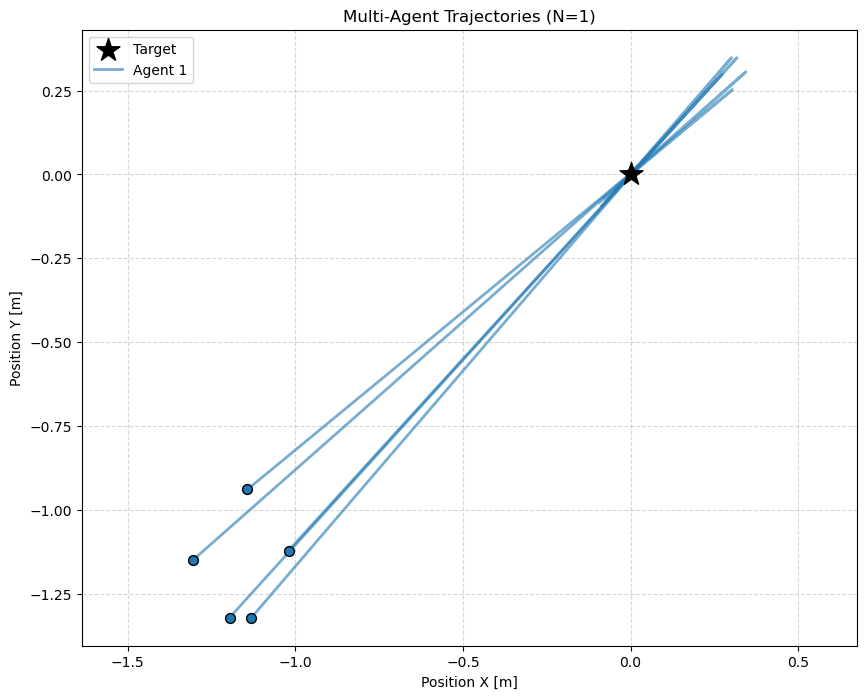

In [6]:
# #sample 10 initial conditions
x0 = dataset.x0_data[:batch_size, :1, :]
u_ext = torch.zeros(batch_size, horizon, input_dim *  n_agents)
traj_y_real = f_sim(x0, horizon, batch_size, u_ext=u_ext, output_noise=None)
# # Run the plotter
plot_trajectories(traj_y_real)

## Training assuming no model mismatch (simulated model = nominal model)


### Define simulated model

In [7]:
#Ren
ren = ContractiveREN(dim_in=state_dim*n_agents, dim_out=input_dim*n_agents, dim_internal=dim_internal, dim_nl=dim_nl, initialization_std=initialization_std)

#Closed loop of Performance boosting controller and simulator of closed loop
PB_closed_loop_sim = PBClosedLoop(ren, f_sim, f_nom)

### Training loop


Starting training on cpu...
Epoch 1/200 | Train Loss: 0.1339 | Val Loss: 0.1466 | Time: 0.36s (Total: 0.36 sec)
Epoch 2/200 | Train Loss: 0.1338 | Val Loss: 0.1465 | Time: 0.36s (Total: 0.72 sec)
Epoch 3/200 | Train Loss: 0.1337 | Val Loss: 0.1464 | Time: 0.41s (Total: 1.13 sec)
Epoch 4/200 | Train Loss: 0.1336 | Val Loss: 0.1463 | Time: 0.36s (Total: 1.50 sec)
Epoch 5/200 | Train Loss: 0.1335 | Val Loss: 0.1462 | Time: 0.37s (Total: 1.86 sec)
Epoch 6/200 | Train Loss: 0.1334 | Val Loss: 0.1461 | Time: 0.35s (Total: 2.21 sec)
Epoch 7/200 | Train Loss: 0.1333 | Val Loss: 0.1460 | Time: 0.35s (Total: 2.56 sec)
Epoch 8/200 | Train Loss: 0.1332 | Val Loss: 0.1459 | Time: 0.36s (Total: 2.92 sec)
Epoch 9/200 | Train Loss: 0.1331 | Val Loss: 0.1458 | Time: 0.35s (Total: 3.27 sec)
Epoch 10/200 | Train Loss: 0.1330 | Val Loss: 0.1457 | Time: 0.36s (Total: 3.63 sec)
Epoch 11/200 | Train Loss: 0.1329 | Val Loss: 0.1455 | Time: 0.36s (Total: 3.99 sec)
Epoch 12/200 | Train Loss: 0.1328 | Val Loss: 

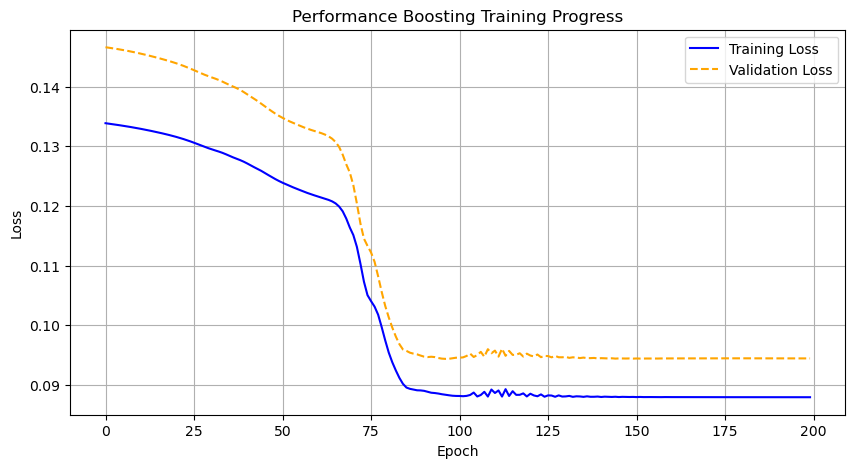

In [8]:
#Instantiate loss and Move to Device
loss_fn = PBLoss(x_target, Q, R, alpha_obs=alpha_obs,
                 obs_centers=obs_centers, obs_sigmas=obs_sigmas, n_agents=n_agents)

loss_fn.to(device) #Moves Q, R, target, and obstacles to GPU

optimizer = torch.optim.Adam(PB_closed_loop_sim.parameters(), lr=lr)

# Lists to store history for plotting
all_traj_x_train = []
all_traj_u_train = []
all_traj_w_hat_train = []
train_losses = []
all_traj_x_val= []
all_traj_u_val = []
all_traj_w_hat_val = []
val_losses = []

# Track total training time
start_time = time.time()

print(f"Starting training on {device}...")

for epoch in range(num_epochs):
    epoch_start_time = time.time()

    # --- TRAINING PHASE ---
    PB_closed_loop_sim.train()  # Set model to training mode
    total_train_loss = 0

    for batch_w in train_loader:
        # Move the entire batch to device
        batch_w = batch_w.to(device)

        # 1. Run Simulation
        # The controller generates the full trajectory based on input w
        traj_x_train, traj_u_train, traj_w_hat_train = PB_closed_loop_sim.run(batch_w)

        # 2. Compute Loss
        # Note: Your loss_fn returns (total_loss, breakdown_dict_or_values)
        loss, _, _, _ = loss_fn(traj_x_train, traj_u_train)

        # 3. Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

        #Store Trajectories for Plotting
        all_traj_x_train.append(traj_x_train.cpu())
        all_traj_u_train.append(traj_u_train.cpu())
        all_traj_w_hat_train.append(traj_w_hat_train.cpu())

    # Compute average training loss for this epoch
    avg_train_loss = total_train_loss / len(train_loader) if len(train_loader) > 0 else 0
    train_losses.append(avg_train_loss)

    # --- VALIDATION PHASE ---
    PB_closed_loop_sim.eval()  # Set model to evaluation mode (disable dropout, etc.)
    total_val_loss = 0

    with torch.no_grad():  # Disable gradient calculation for efficiency
        for batch_w_val in val_loader:
            batch_w_val = batch_w_val.to(device)

            # Run simulation without storing gradients
            traj_x_val, traj_u_val, traj_w_hat_val = PB_closed_loop_sim.run(batch_w_val)

            # Compute validation loss
            val_loss, _, _, _ = loss_fn(traj_x_val, traj_u_val)
            total_val_loss += val_loss.item()

            #Store Trajectories for Plotting
            all_traj_x_val.append(traj_x_val.cpu())
            all_traj_u_val.append(traj_u_val.cpu())
            all_traj_w_hat_val.append(traj_w_hat_val.cpu())

    # Compute average validation loss
    avg_val_loss = total_val_loss / len(val_loader) if len(val_loader) > 0 else 0
    val_losses.append(avg_val_loss)

    # --- LOGGING ---
    epoch_duration = time.time() - epoch_start_time
    elapsed_time = time.time() - start_time

    # Print progress every epoch (or every N epochs to reduce clutter)
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Time: {epoch_duration:.2f}s (Total: {elapsed_time:.2f} sec)")

# Concatenate all batches into single tensors for easy indexing
# Shape: [Total_Test_Samples, Time_Steps, State_Dim]
all_traj_x_train = torch.cat(all_traj_x_train, dim=0)
all_traj_u_train = torch.cat(all_traj_u_train, dim=0)
all_traj_w_hat_train = torch.cat(all_traj_w_hat_train, dim=0)

all_traj_x_val = torch.cat(all_traj_x_val, dim=0)
all_traj_u_val = torch.cat(all_traj_u_val, dim=0)
all_traj_w_hat_val = torch.cat(all_traj_w_hat_val, dim=0)

# --- PLOTTING ---
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='orange', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Performance Boosting Training Progress')
plt.legend()
plt.grid(True)
plt.show()

## Plots


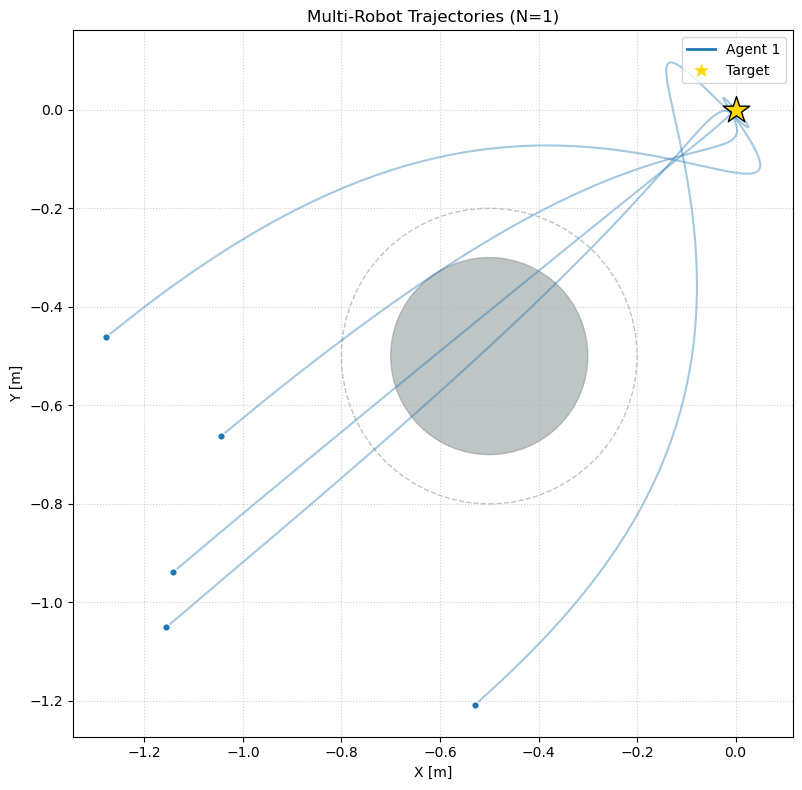

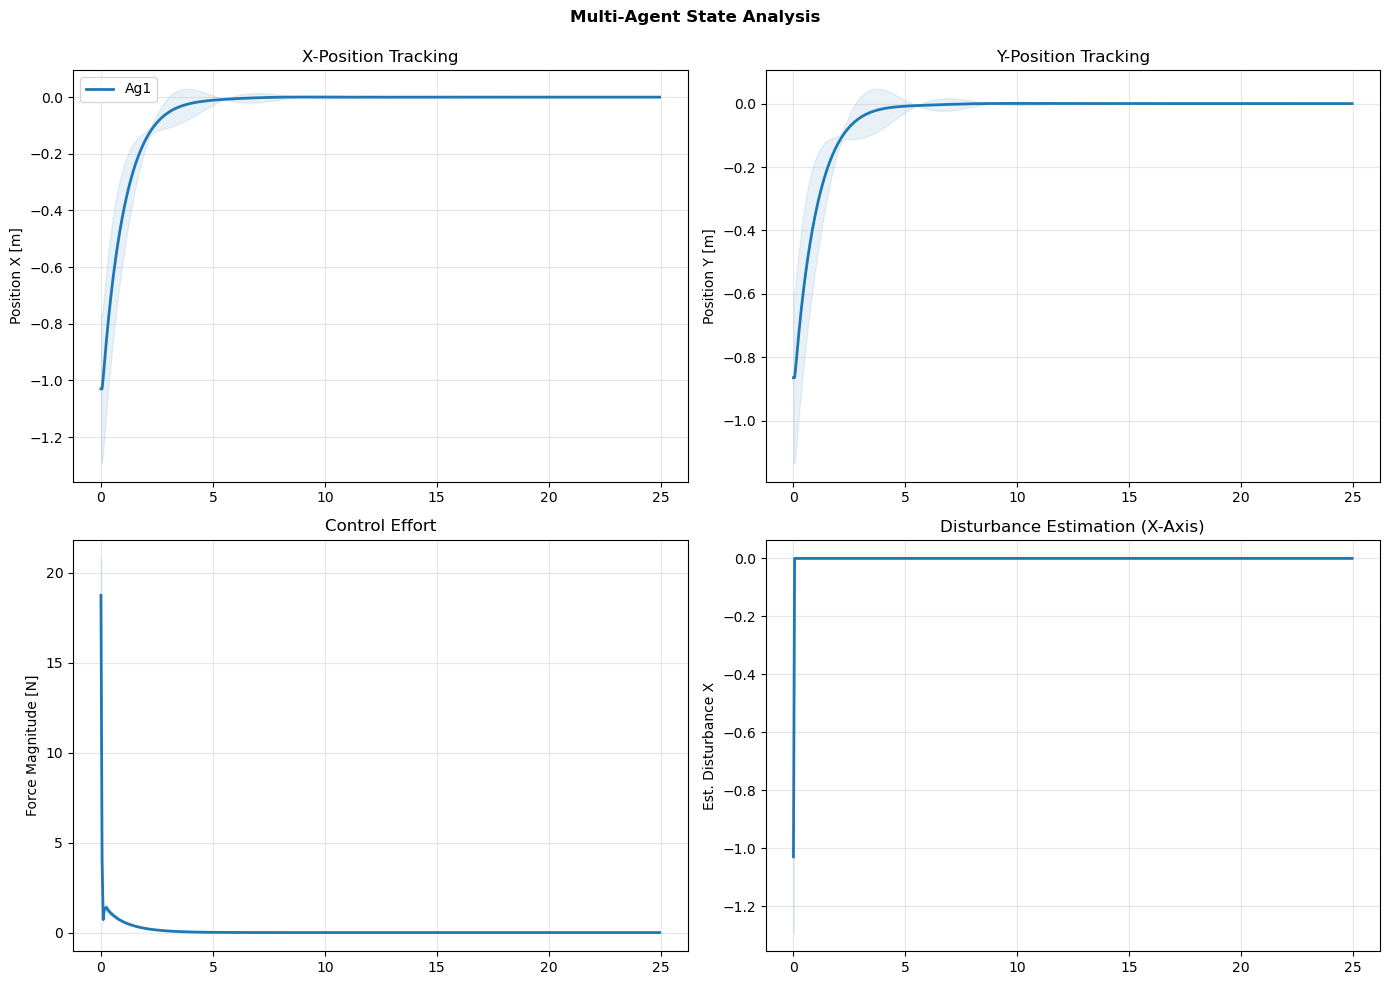

In [9]:
plot_pb_trajectories(
    traj_x=traj_x_train,
    traj_u=traj_u_train,
    traj_w_hat=traj_w_hat_train,
    x_target=x_target,
    obs_centers=obs_centers,
    obs_sigma=obs_sigmas,
    dt=dt
)

## Testing

Starting testing on cpu...
Testing Complete. Average Test Loss: 0.1118


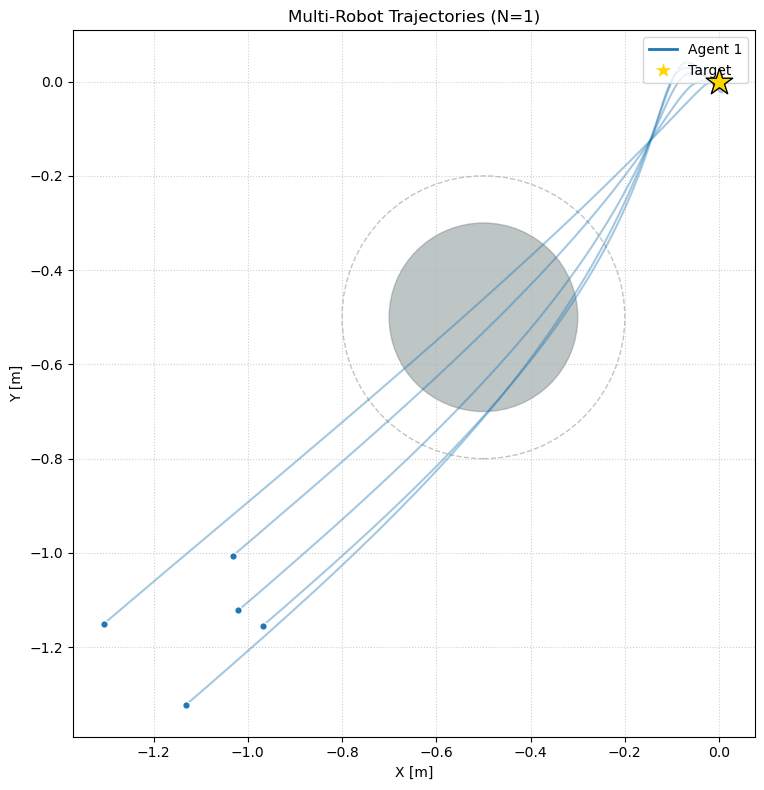

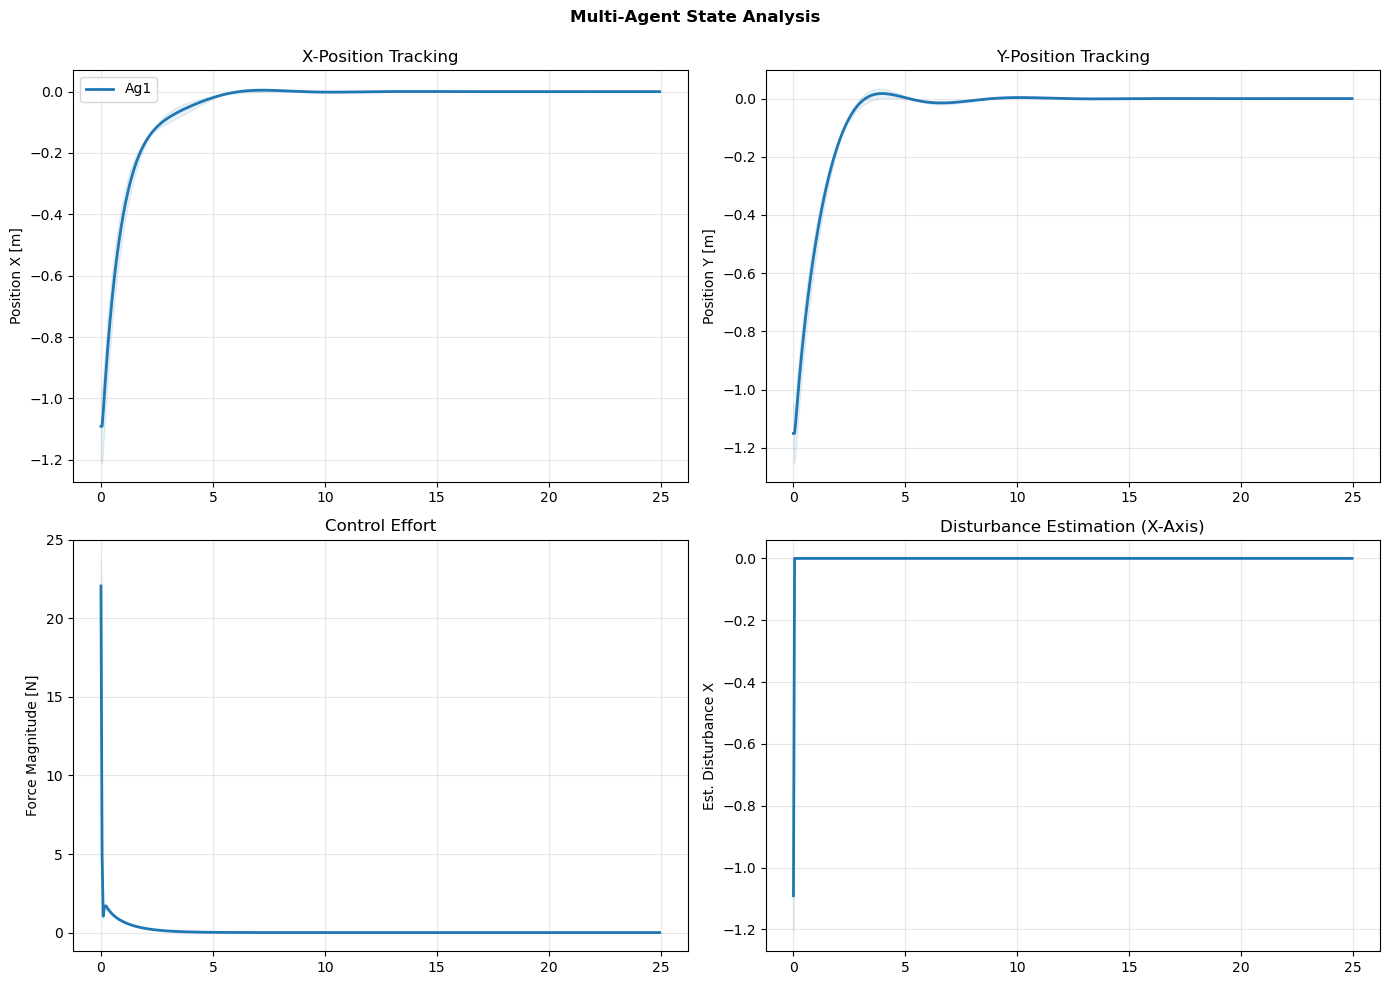

In [10]:
# --- PREPARATION ---
PB_closed_loop_sim.eval()  # Set model to evaluation mode
test_losses = []
all_traj_x_test = []
all_traj_u_test = []
all_traj_w_hat_test = []


print(f"Starting testing on {device}...")

# --- TESTING LOOP ---
with torch.no_grad():
    for i, batch_w_test in enumerate(test_loader):
        batch_w_test = batch_w_test.to(device)

        # 1. Run Simulation
        # The controller generates the trajectories for the test batch
        traj_x_test, traj_u_test, traj_w_hat_test = PB_closed_loop_sim.run(batch_w_test)

        # --- STABILITY CHECK ---
        # Check 1: Did the numbers explode to Infinity or NaN?
        is_nan = torch.isnan(traj_x_test).any()
        is_inf = torch.isinf(traj_x_test).any()

        # Check 2: Did they exceed a physical safety limit? (e.g., 1000 meters/units)
        # This catches instability before it hits "Infinity"
        exceeds_bounds = torch.max(torch.abs(traj_x_test)) > 1e4

        if is_nan or is_inf or exceeds_bounds:
            print(f"⚠️ BATCH {i}:️ SYSTEM IS UNSTABLE!")
            if is_nan: print("   -> Detected NaNs (Not a Number)")
            if is_inf: print("   -> Detected Infs (Infinity)")
            if exceeds_bounds: print(f"   -> Value explosion (Max value: {torch.max(torch.abs(traj_x_test)):.2f})")

        # 2. Compute Test Loss (Optional, for metric tracking)
        loss, _, _, _ = loss_fn(traj_x_test, traj_u_test)
        test_losses.append(loss.item())

        # 3. Store Trajectories for Plotting
        # Move to CPU immediately to free GPU and prepare for Matplotlib
        all_traj_x_test.append(traj_x_test.cpu())
        all_traj_u_test.append(traj_u_test.cpu())
        all_traj_w_hat_test.append(traj_w_hat_test.cpu())

# Concatenate all batches into single tensors for easy indexing
# Shape: [Total_Test_Samples, Time_Steps, State_Dim]
all_traj_x_test = torch.cat(all_traj_x_test, dim=0)
all_traj_u_test = torch.cat(all_traj_u_test, dim=0)
all_traj_w_hat_test = torch.cat(all_traj_w_hat_test, dim=0)

# Calculate average loss
avg_test_loss = sum(test_losses) / len(test_loader)
print(f"Testing Complete. Average Test Loss: {avg_test_loss:.4f}")

plot_pb_trajectories(
    traj_x=traj_x_test,
    traj_u=traj_u_test,
    traj_w_hat=traj_w_hat_test,
    x_target=x_target,
    obs_centers=obs_centers,
    obs_sigma=obs_sigmas,
    dt=dt)